TASK A DATASET PREPARATION

In [ ]:
print("KRITHIKA K--24BAD061")
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from datasets import load_dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


KRITHIKA K--24BAD061


In [ ]:
dataset = load_dataset("Trelis/tiny-shakespeare")

print(dataset)

README.md:   0%|          | 0.00/497 [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/119k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/472 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/49 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Text'],
        num_rows: 472
    })
    test: Dataset({
        features: ['Text'],
        num_rows: 49
    })
})


In [ ]:
print("Dataset splits: ")
print(dataset.keys())

for split in dataset.keys():
  print("\nSplit: ",split)
  print(dataset[split])
  print("Number of samples: ",len(dataset[split]))

Dataset splits: 
dict_keys(['train', 'test'])

Split:  train
Dataset({
    features: ['Text'],
    num_rows: 472
})
Number of samples:  472

Split:  test
Dataset({
    features: ['Text'],
    num_rows: 49
})
Number of samples:  49


In [ ]:
print("First few text samples:\n")

for i in range(min(5, len(dataset["train"]))):
    print("Sample", i + 1)
    print(dataset["train"][i])
    print("-" * 60)

First few text samples:

Sample 1
{'Text': "First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to die than to famish?\n\nAll:\nResolved. resolved.\n\nFirst Citizen:\nFirst, you know Caius Marcius is chief enemy to the people.\n\nAll:\nWe know't, we know't.\n\nFirst Citizen:\nLet us kill him, and we'll have corn at our own price.\nIs't a verdict?\n\nAll:\nNo more talking on't; let it be done: away, away!\n\nSecond Citizen:\nOne word, good citizens.\n\nFirst Citizen:\nWe are accounted poor citizens, the patricians good.\nWhat authority surfeits on would relieve us: if they\nwould yield us but the superfluity, while it were\nwholesome, we might guess they relieved us humanely;\nbut they think we are too dear: the leanness that\nafflicts us, the object of our misery, is as an\ninventory to particularise their abundance; our\nsufferance is a gain to them Let us revenge this with\nour pikes, ere we become rakes:

In [ ]:
print(dataset["train"].column_names)

['Text']


In [ ]:
text_column = dataset["train"].column_names[0]

text = " ".join(dataset["train"][text_column])

print("Total characters:", len(text))
print("\nFirst 1000 characters:\n")
print(text[:1000])

Total characters: 1222825

First 1000 characters:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak thi

In [ ]:
text = text.lower()

print("Lowercase text sample:\n")
print(text[:1000])

Lowercase text sample:

first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know't.

first citizen:
let us kill him, and we'll have corn at our own price.
is't a verdict?

all:
no more talking on't; let it be done: away, away!

second citizen:
one word, good citizens.

first citizen:
we are accounted poor citizens, the patricians good.
what authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them let us revenge this with
our pikes, ere we become rakes: for the gods know i
speak this in hunger for bread, not 

In [ ]:
tokenizer = Tokenizer(
    oov_token="<OOV>",
    filters='!"#$%&()*+,-./:;=?@[\\]^_`{|}~\t\n'
)

tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary size:", total_words)
print("\nFirst 20 words in vocabulary:")

for word, index in list(tokenizer.word_index.items())[:20]:
    print(word, ":", index)

Vocabulary size: 11981

First 20 words in vocabulary:
<OOV> : 1
the : 2
and : 3
to : 4
i : 5
of : 6
my : 7
you : 8
a : 9
that : 10
in : 11
is : 12
not : 13
for : 14
with : 15
me : 16
it : 17
your : 18
be : 19
his : 20


In [ ]:
token_list = tokenizer.texts_to_sequences([text])[0]

print("Number of tokens:", len(token_list))
print("\nFirst 30 token values:")print(token_list[:30])

Number of tokens: 223886

First 30 token values:
[80, 261, 150, 35, 876, 149, 651, 128, 16, 107, 36, 107, 107, 80, 261, 8, 42, 36, 1383, 348, 4, 193, 66, 4, 4237, 36, 1383, 1383, 80, 261]


In [ ]:
sequence_length = 10

input_sequences = []

for i in range(sequence_length, len(token_list)):
    sequence = token_list[i-sequence_length:i+1]
    input_sequences.append(sequence)

input_sequences = np.array(input_sequences)

print("Total input sequences:", len(input_sequences))
print("Sequence shape:", input_sequences.shape)
print("\nExample sequence:")
print(input_sequences[0])

Total input sequences: 223876
Sequence shape: (223876, 11)

Example sequence:
[ 80 261 150  35 876 149 651 128  16 107  36]


In [ ]:
max_sequence_length = sequence_length + 1

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_sequence_length,
    padding="pre"
)

print("Shape after padding:", input_sequences.shape)
print("\nFirst padded sequence:")
print(input_sequences[0])

Shape after padding: (223876, 11)

First padded sequence:
[ 80 261 150  35 876 149 651 128  16 107  36]


In [ ]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("Input X shape:", X.shape)
print("Target y shape:", y.shape)

print("\nExample:")
print("Input:", X[0])
print("Target:", y[0])

Input X shape: (223876, 10)
Target y shape: (223876,)

Example:
Input: [ 80 261 150  35 876 149 651 128  16 107]
Target: 36


In [ ]:
split_index = int(len(X) * 0.8)

X_train = X[:split_index]
y_train = y[:split_index]

X_val = X[split_index:]
y_val = y[split_index:]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

print("\nTraining input shape:", X_train.shape)
print("Validation input shape:", X_val.shape)

Training samples: 179100
Validation samples: 44776

Training input shape: (179100, 10)
Validation input shape: (44776, 10)


In [ ]:
print("Prepared dataset successfully.")

print("\nTraining data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nValidation data:")
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

Prepared dataset successfully.

Training data:
X_train: (179100, 10)
y_train: (179100,)

Validation data:
X_val: (44776, 10)
y_val: (44776,)


TASK B: IMPLEMENTING THE RNN MODEL

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

embedding_dim = 64
rnn_units = 128

model = Sequential([
    Embedding(
        input_dim=total_words,
        output_dim=embedding_dim
    ),

    SimpleRNN(
        rnn_units
    ),

    Dense(
        total_words,
        activation="softmax"
    )
])

print("RNN model created successfully.")

RNN model created successfully.


In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

model.summary()

Model compiled successfully.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

TASK C — TRAINING AND PERFORMANCE EVALUATION

In [22]:
epochs = 10

history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=256,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 135s 194ms/step - accuracy: 0.0388 - loss: 6.7184 - val_accuracy: 0.0479 - val_loss: 6.8685
Epoch 2/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 120s 171ms/step - accuracy: 0.0712 - loss: 6.2277 - val_accuracy: 0.0744 - val_loss: 6.7253
Epoch 3/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 146s 177ms/step - accuracy: 0.0906 - loss: 5.8779 - val_accuracy: 0.0774 - val_loss: 6.7491
Epoch 4/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 124s 177ms/step - accuracy: 0.1022 - loss: 5.5938 - val_accuracy: 0.0821 - val_loss: 6.7750
Epoch 5/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 117s 167ms/step - accuracy: 0.1143 - loss: 5.3408 - val_accuracy: 0.0801 - val_loss: 6.8607
Epoch 6/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 149s 178ms/step - accuracy: 0.1286 - loss: 5.1079 - val_accuracy: 0.0785 - val_loss: 6.9596
Epoch 7/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 118s 169ms/step - accuracy: 0.1456 - loss: 4.8891 - val_accuracy: 0.0785 - val_loss: 7.0483
Epoch 8/10
700/700 ━━━━━━━━━━━━━━━━━━━━ 140s 167ms/step - accuracy: 0.1642 -

In [23]:
train_loss, train_accuracy = model.evaluate(
    X_train,
    y_train,
    verbose=0
)

val_loss, val_accuracy = model.evaluate(
    X_val,
    y_val,
    verbose=0
)

print("Student Roll No: 24BAD061")
print("\nFinal Performance")
print("-" * 40)

print("Training Loss     :", train_loss)
print("Training Accuracy :", train_accuracy)

print("Validation Loss     :", val_loss)
print("Validation Accuracy :", val_accuracy)

Student Roll No: 24BAD061

Final Performance
----------------------------------------
Training Loss     : 4.0024189949035645
Training Accuracy : 0.25290897488594055
Validation Loss     : 7.381101131439209
Validation Accuracy : 0.07052885740995407


In [24]:
print("Epoch-wise Accuracy")
print("-" * 50)

for i in range(epochs):
    print(
        f"Epoch {i+1}: "
        f"Training Accuracy = {history.history['accuracy'][i]:.4f}, "
        f"Validation Accuracy = {history.history['val_accuracy'][i]:.4f}"
    )

Epoch-wise Accuracy
--------------------------------------------------
Epoch 1: Training Accuracy = 0.0388, Validation Accuracy = 0.0479
Epoch 2: Training Accuracy = 0.0712, Validation Accuracy = 0.0744
Epoch 3: Training Accuracy = 0.0906, Validation Accuracy = 0.0774
Epoch 4: Training Accuracy = 0.1022, Validation Accuracy = 0.0821
Epoch 5: Training Accuracy = 0.1143, Validation Accuracy = 0.0801
Epoch 6: Training Accuracy = 0.1286, Validation Accuracy = 0.0785
Epoch 7: Training Accuracy = 0.1456, Validation Accuracy = 0.0785
Epoch 8: Training Accuracy = 0.1642, Validation Accuracy = 0.0735
Epoch 9: Training Accuracy = 0.1876, Validation Accuracy = 0.0733
Epoch 10: Training Accuracy = 0.2107, Validation Accuracy = 0.0705


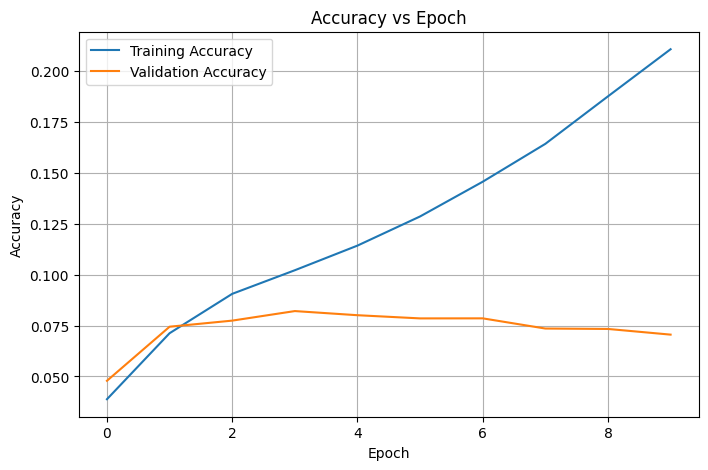

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

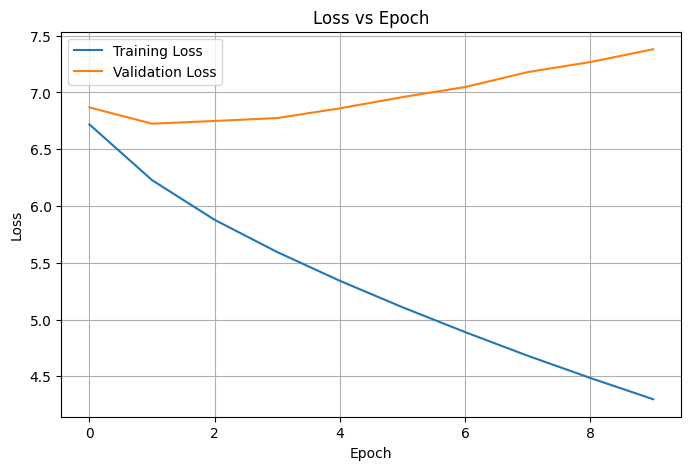

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

TASK D — TEXT GENERATION

In [27]:
def generate_text(seed_text, next_words=20):

    generated_text = seed_text.lower()

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences(
            [generated_text]
        )[0]

        token_list = token_list[-sequence_length:]

        token_list = pad_sequences(
            [token_list],
            maxlen=sequence_length,
            padding="pre"
        )

        predicted_probabilities = model.predict(
            token_list,
            verbose=0
        )

        predicted_word_index = np.argmax(
            predicted_probabilities,
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted_word_index:
                output_word = word
                break

        if output_word == "":
            break

        generated_text += " " + output_word

    return generated_text

In [28]:
seed_text = "to be or not"
generated_text = generate_text(
    seed_text,
    next_words=20
)
print("Student Roll No: 24BAD061")
print("\nSeed Text:")
print(seed_text)

print("\nGenerated Text:")
print(generated_text)

Student Roll No: 24BAD061

Seed Text:
to be or not

Generated Text:
to be or not that they have heard it is a king and all the rest of heaven and all the world of this


In [29]:
seed_texts = [
    "to be or not",
    "the king",
    "my lord",
    "love is",
    "i will"
]
for seed in seed_texts:
    generated = generate_text(
        seed,
        next_words=20
    )
    print("=" * 70)
    print("Seed:", seed)
    print("Generated:", generated)

Seed: to be or not
Generated: to be or not that they have heard it is a king and all the rest of heaven and all the world of this
Seed: the king
Generated: the king is dead and smooth the rest and many men with a sop of them and i am sure i have
Seed: my lord
Generated: my lord i am not for this ambling day my father is my gracious lord king richard iii why then i am
Seed: love is
Generated: love is dead queen margaret ay ay my lord i am not for a guest as i have bought the mansion of
Seed: i will
Generated: i will tell thee and i am too well to make the world of heaven and the moveables the king that i
